# Synthèse des expérimentations

## Objectif

Ce notebook regroupe l'ensemble des résultats obtenus au cours des expérimentations réalisées sur les données mensuelles de consommation de carburant.

Les modèles étudiés sont :

- Random Forest
- XGBoost
- SARIMA
- LSTM

Les expérimentations ont été conduites selon plusieurs stratégies :

- modèle global
- modèles par produit
- modèles par segment de comportement
- modèle univarié SARIMA

L'objectif est d'identifier la stratégie la plus adaptée au problème de prévision des consommations de carburant.

## Import

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns",None)

In [5]:
rf = pd.DataFrame([
    ["RF Global",5431.77,8134.90,26.33,0.9014],
    ["RF Essence",5887.00,8871.49,26.33,0.9227],
    ["RF Gasoil",5410.54,8002.31,27.87,0.7879]
],columns=["Modele","MAE","RMSE","MAPE","R2"])

xgb = pd.DataFrame([
    ["XGB Global",5512.46,8115.79,27.75,0.9019],
    ["XGB Essence",6155.33,8979.80,29.05,0.9208],
    ["XGB Gasoil",5926.40,9315.97,29.37,0.7125]
],columns=["Modele","MAE","RMSE","MAPE","R2"])

lstm = pd.DataFrame([
    ["LSTM Global",7972.59,13471.25,41.91,0.7525],
    ["LSTM Essence",7556.45,11348.89,34.78,0.8865],
    ["LSTM Gasoil",7834.09,12387.14,43.87,0.5309]
],columns=["Modele","MAE","RMSE","MAPE","R2"])

sarima = pd.DataFrame([
    ["SARIMA ST0002-A0001",31822,36831,20.9,np.nan],
    ["SARIMA ST0001-A0001",26895,31811,33.5,np.nan],
    ["SARIMA ST0001-A0002",16334,19055,41.0,np.nan],
    ["SARIMA ST0002-A0002",20955,25320,np.nan,np.nan]
],columns=["Modele","MAE","RMSE","MAPE","R2"])

In [36]:
display(rf)
display(xgb)
display(lstm)
display(sarima)

,Modele,MAE,RMSE,MAPE,R2
0,RF Global,5431.77,8134.90,26.33,0.9014
1,RF Essence,5887.00,8871.49,26.33,0.9227
2,RF Gasoil,5410.54,8002.31,27.87,0.7879


,Modele,MAE,RMSE,MAPE,R2
0,XGB Global,5512.46,8115.79,27.75,0.9019
1,XGB Essence,6155.33,8979.80,29.05,0.9208
2,XGB Gasoil,5926.40,9315.97,29.37,0.7125


,Modele,MAE,RMSE,MAPE,R2
0,LSTM Global,7972.59,13471.25,41.91,0.7525
1,LSTM Essence,7556.45,11348.89,34.78,0.8865
2,LSTM Gasoil,7834.09,12387.14,43.87,0.5309


,Modele,MAE,RMSE,MAPE,R2
0,SARIMA ST0002-A0001,31822,36831,20.9,NaN
1,SARIMA ST0001-A0001,26895,31811,33.5,NaN
2,SARIMA ST0001-A0002,16334,19055,41.0,NaN
3,SARIMA ST0002-A0002,20955,25320,NaN,NaN


In [7]:
resume=pd.concat(
[
rf,
xgb,
lstm
],
ignore_index=True
)

resume

,Modele,MAE,RMSE,MAPE,R2
0,RF Global,5431.77,8134.90,26.33,0.9014
1,RF Essence,5887.00,8871.49,26.33,0.9227
2,RF Gasoil,5410.54,8002.31,27.87,0.7879
3,XGB Global,5512.46,8115.79,27.75,0.9019
4,XGB Essence,6155.33,8979.80,29.05,0.9208
5,XGB Gasoil,5926.40,9315.97,29.37,0.7125
6,LSTM Global,7972.59,13471.25,41.91,0.7525
7,LSTM Essence,7556.45,11348.89,34.78,0.8865
8,LSTM Gasoil,7834.09,12387.14,43.87,0.5309


In [9]:
resume.to_csv(
"resume_global_modeles.csv",
index=False
)

print("Résumé sauvegardé.")

Résumé sauvegardé.


## Graphique comparatif des modèles ML

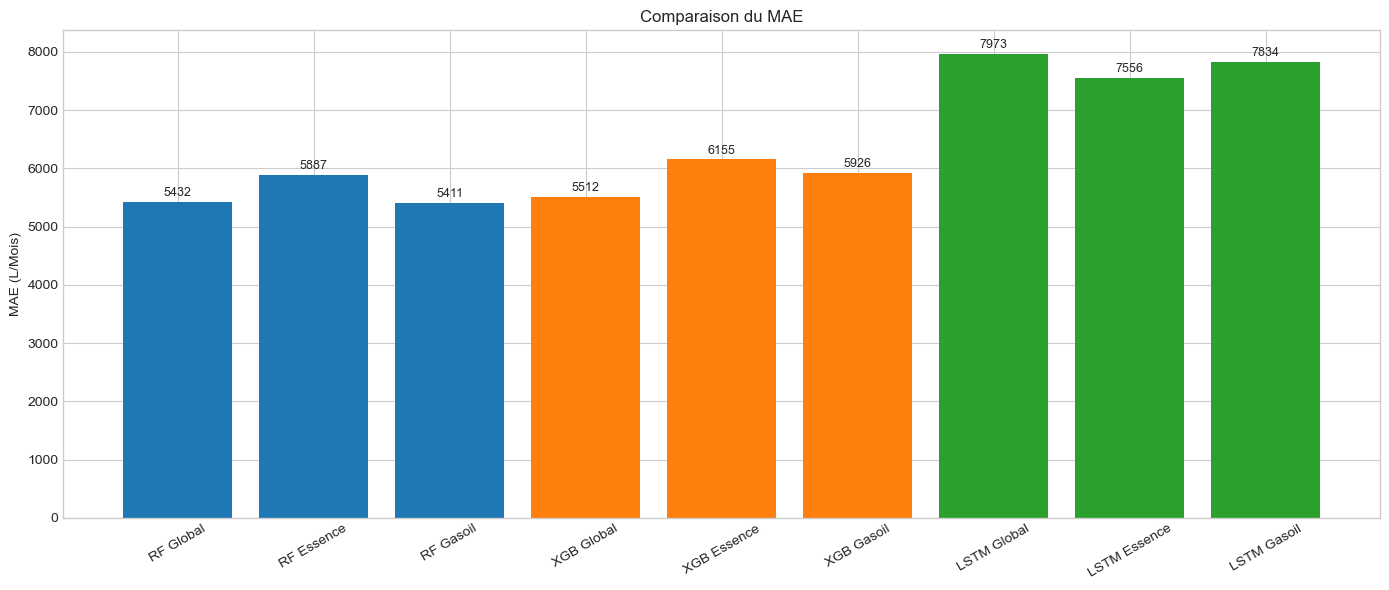

In [11]:
plt.figure(figsize=(14,6))

couleurs=[]

for modele in resume.Modele:

    if "RF" in modele:
        couleurs.append("#1f77b4")

    elif "XGB" in modele:
        couleurs.append("#ff7f0e")

    else:
        couleurs.append("#2ca02c")

bars=plt.bar(
resume.Modele,
resume.MAE,
color=couleurs
)

plt.xticks(rotation=30)

plt.ylabel("MAE (L/Mois)")

plt.title("Comparaison du MAE")

for b in bars:

    y=b.get_height()

    plt.text(
        b.get_x()+b.get_width()/2,
        y+100,
        f"{y:.0f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

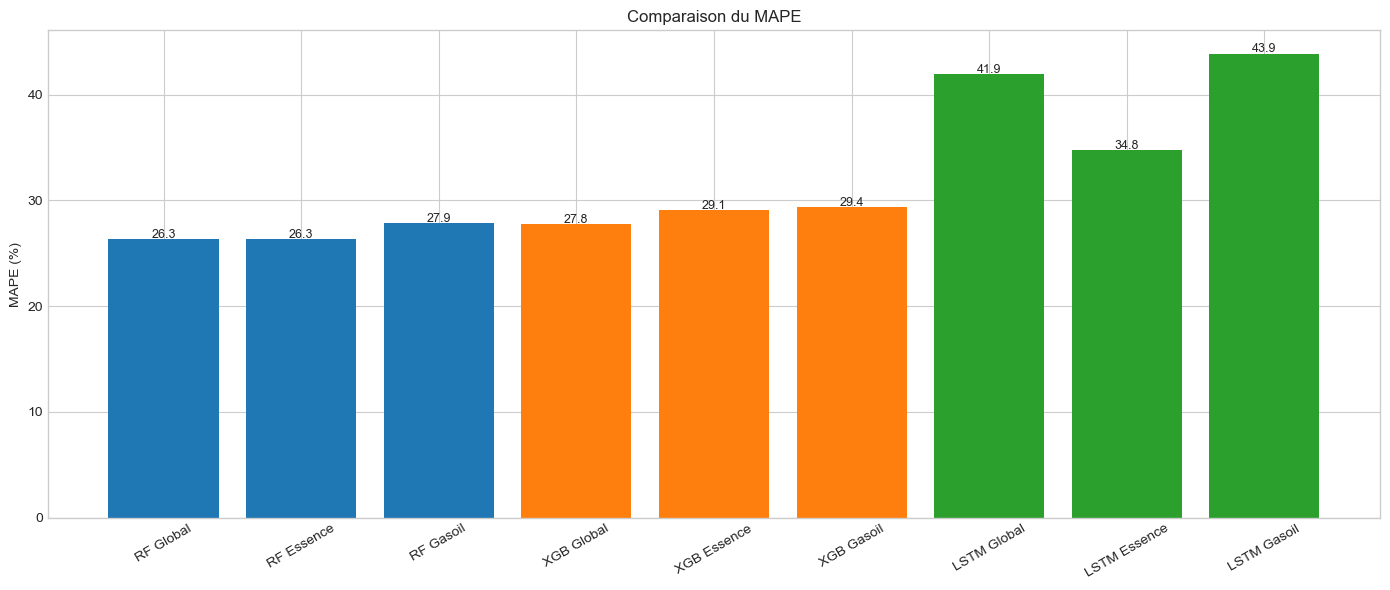

In [21]:
plt.figure(figsize=(14,6))

couleurs=[]

for modele in resume.Modele:

    if "RF" in modele:
        couleurs.append("#1f77b4")

    elif "XGB" in modele:
        couleurs.append("#ff7f0e")

    else:
        couleurs.append("#2ca02c")

bars=plt.bar(
resume.Modele,
resume.MAPE,
color=couleurs
)

plt.xticks(rotation=30)

plt.ylabel("MAPE (%)")

plt.title("Comparaison du MAPE")

for b in bars:

    y=b.get_height()

    plt.text(
        b.get_x()+b.get_width()/2,
        y+0.1,
        f"{y:.1f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

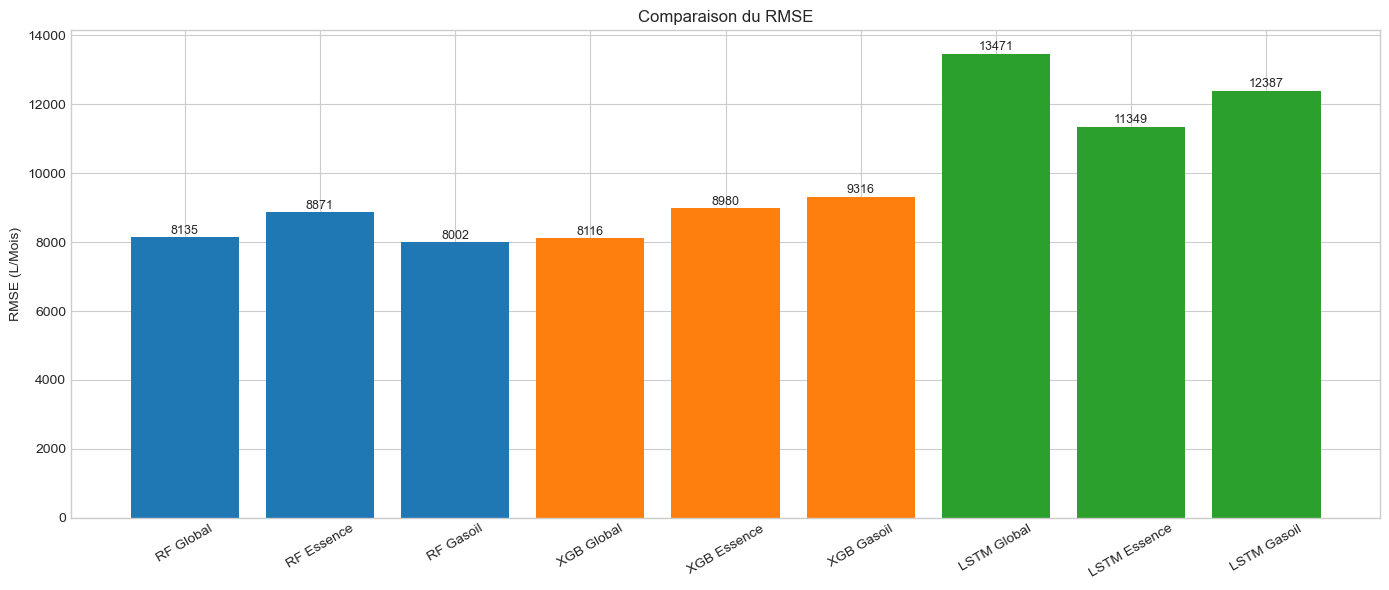

In [48]:
plt.figure(figsize=(14,6))

couleurs=[]

for modele in resume.Modele:

    if "RF" in modele:
        couleurs.append("#1f77b4")

    elif "XGB" in modele:
        couleurs.append("#ff7f0e")

    else:
        couleurs.append("#2ca02c")

bars=plt.bar(
resume.Modele,
resume.RMSE,
color=couleurs
)

plt.xticks(rotation=30)

plt.ylabel("RMSE (L/Mois)")

plt.title("Comparaison du RMSE")

for b in bars:

    y=b.get_height()

    plt.text(
        b.get_x()+b.get_width()/2,
        y+100,
        f"{y:.0f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

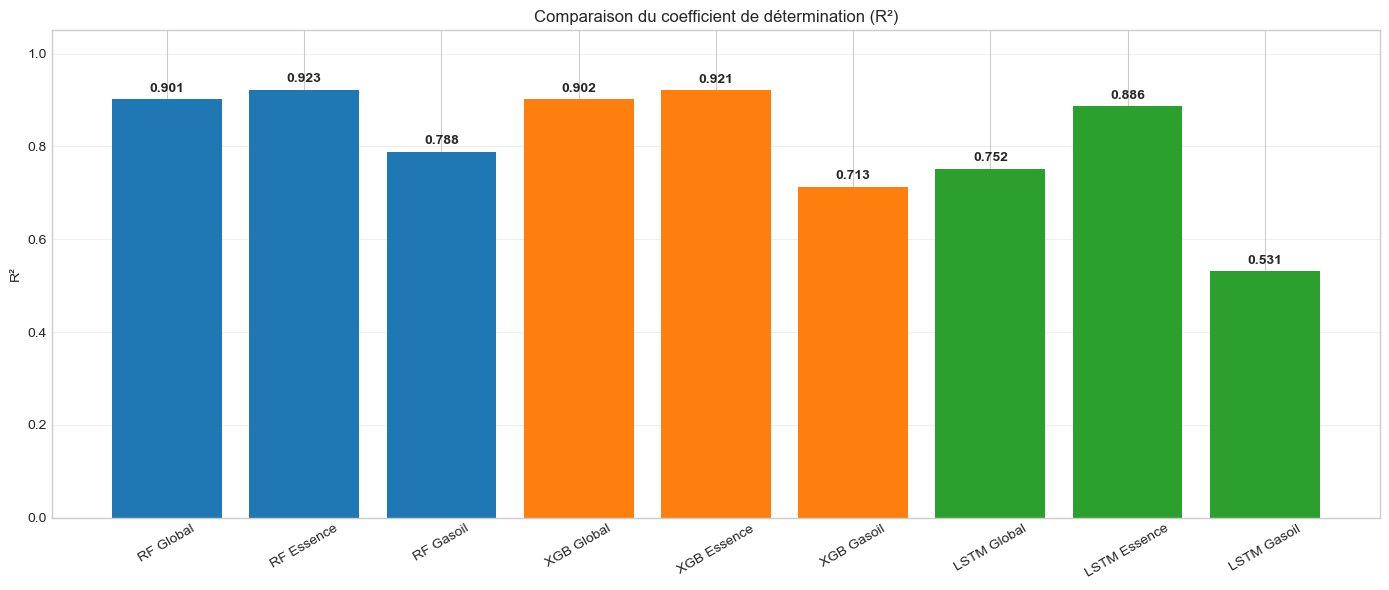

In [58]:
plt.figure(figsize=(14,6))

couleurs = []

for modele in resume.Modele:

    if "RF" in modele:
        couleurs.append("#1f77b4")      # Bleu

    elif "XGB" in modele:
        couleurs.append("#ff7f0e")      # Orange

    else:
        couleurs.append("#2ca02c")      # Vert (LSTM)

bars = plt.bar(
    resume.Modele,
    resume.R2,
    color=couleurs
)

plt.xticks(rotation=30)
plt.ylabel("R²")
plt.title("Comparaison du coefficient de détermination (R²)")
plt.ylim(0, 1.05)

# Affichage des valeurs sur les colonnes
for b in bars:

    y = b.get_height()

    plt.text(
        b.get_x() + b.get_width()/2,
        y + 0.01,
        f"{y:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

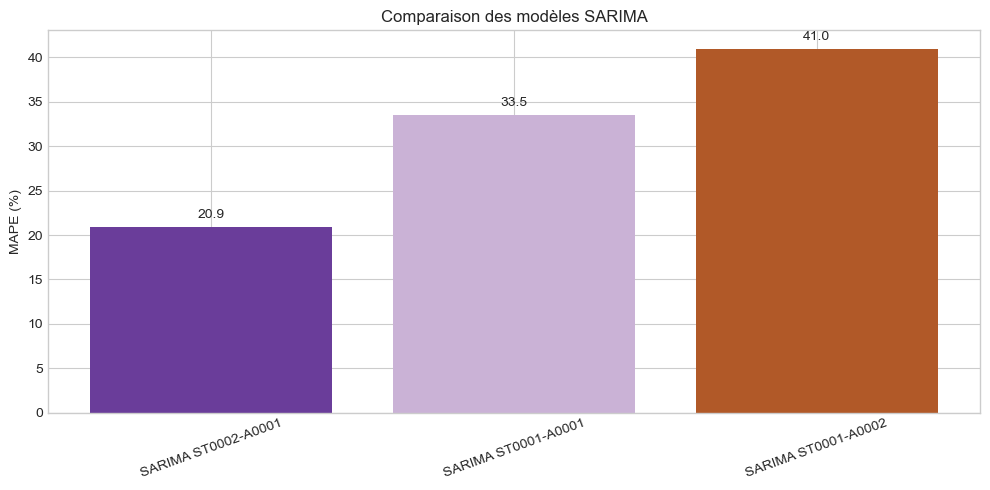

In [52]:
plt.figure(figsize=(10,5))

couleurs=["#6a3d9a","#cab2d6","#b15928","#fb9a99"]

bars=plt.bar(
sarima.Modele,
sarima.MAPE,
color=couleurs
)

plt.ylabel("MAPE (%)")

plt.xticks(rotation=20)

plt.title("Comparaison des modèles SARIMA")

for b in bars:

    if np.isnan(b.get_height()):
        continue

    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height()+1,
        f"{b.get_height():.1f}",
        ha="center"
    )

plt.tight_layout()

plt.show()

In [54]:
classement = resume.sort_values(
    "MAPE"
)

classement

,Modele,MAE,RMSE,MAPE,R2
0,RF Global,5431.77,8134.90,26.33,0.9014
1,RF Essence,5887.00,8871.49,26.33,0.9227
3,XGB Global,5512.46,8115.79,27.75,0.9019
2,RF Gasoil,5410.54,8002.31,27.87,0.7879
4,XGB Essence,6155.33,8979.80,29.05,0.9208
5,XGB Gasoil,5926.40,9315.97,29.37,0.7125
7,LSTM Essence,7556.45,11348.89,34.78,0.8865
6,LSTM Global,7972.59,13471.25,41.91,0.7525
8,LSTM Gasoil,7834.09,12387.14,43.87,0.5309


In [56]:
print("="*80)
print("SYNTHÈSE DES EXPÉRIMENTATIONS")
print("="*80)

print()

print("Meilleur modèle (MAPE) :")
display(classement.head())

print()

print("Meilleur RF :",rf.loc[rf.MAPE.idxmin(),"Modele"])

print("Meilleur XGB :",xgb.loc[xgb.MAPE.idxmin(),"Modele"])

print("Meilleur LSTM :",lstm.loc[lstm.MAPE.idxmin(),"Modele"])

print()

print("Meilleur SARIMA :")

display(
sarima.sort_values("MAPE").head(1)
)

SYNTHÈSE DES EXPÉRIMENTATIONS

Meilleur modèle (MAPE) :


,Modele,MAE,RMSE,MAPE,R2
0,RF Global,5431.77,8134.90,26.33,0.9014
1,RF Essence,5887.00,8871.49,26.33,0.9227
3,XGB Global,5512.46,8115.79,27.75,0.9019
2,RF Gasoil,5410.54,8002.31,27.87,0.7879
4,XGB Essence,6155.33,8979.80,29.05,0.9208



Meilleur RF : RF Global
Meilleur XGB : XGB Global
Meilleur LSTM : LSTM Essence

Meilleur SARIMA :


,Modele,MAE,RMSE,MAPE,R2
0,SARIMA ST0002-A0001,31822,36831,20.9,NaN


In [60]:
# ============================================================
# COMPARAISON GLOBALE vs SEGMENTATION
# ============================================================

import pandas as pd

segmentation = pd.DataFrame({

    "Segment": [
        "Stable",
        "Modere",
        "Erratique"
    ],

    "MAPE_Global": [
        23.01,
        27.77,
        35.78
    ],

    "MAPE_Segmente": [
        20.50,
        29.50,
        39.17
    ]

})

# Gain positif = la segmentation améliore le modèle
segmentation["Gain_MAPE"] = (
    segmentation["MAPE_Global"]
    - segmentation["MAPE_Segmente"]
)

segmentation = segmentation.round(2)

print(segmentation)

     Segment  MAPE_Global  MAPE_Segmente  Gain_MAPE
0     Stable        23.01          20.50       2.51
1     Modere        27.77          29.50      -1.73
2  Erratique        35.78          39.17      -3.39


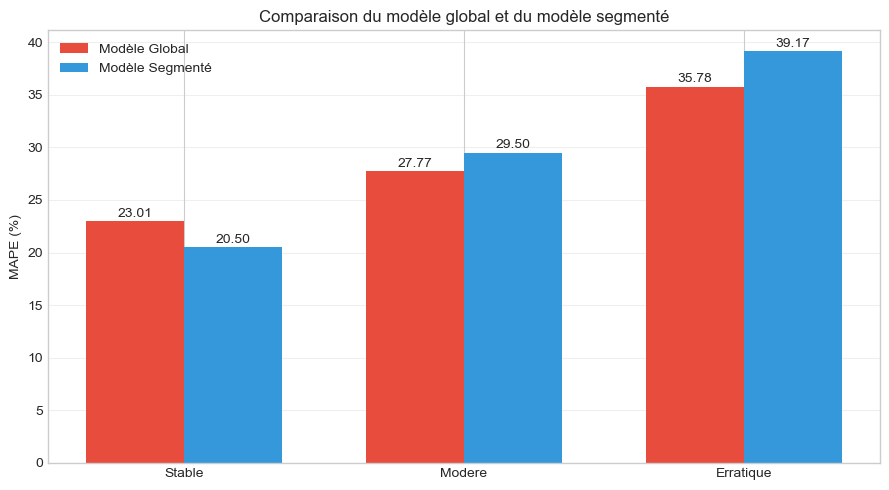

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,5))

x = np.arange(len(segmentation))
width = 0.35

bars1 = plt.bar(
    x-width/2,
    segmentation["MAPE_Global"],
    width,
    color="#E74C3C",
    label="Modèle Global"
)

bars2 = plt.bar(
    x+width/2,
    segmentation["MAPE_Segmente"],
    width,
    color="#3498DB",
    label="Modèle Segmenté"
)

# Etiquettes au-dessus des colonnes
for bars in [bars1, bars2]:
    for b in bars:
        plt.text(
            b.get_x()+b.get_width()/2,
            b.get_height()+0.4,
            f"{b.get_height():.2f}",
            ha="center",
            fontsize=10
        )

plt.xticks(x, segmentation["Segment"])
plt.ylabel("MAPE (%)")
plt.title("Comparaison du modèle global et du modèle segmenté")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "comparaison_global_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Analyse des résultats de la segmentation

La segmentation comportementale n'apporte pas une amélioration uniforme sur l'ensemble des segments.

- **Segment Stable** :
  le modèle dédié obtient un MAPE de **20,50 %**, contre **23,01 %** pour le modèle global,
  soit un gain de **2,51 points**. La segmentation est donc pertinente pour les couples présentant un comportement de consommation régulier.

- **Segment Modéré** :
  le modèle global reste légèrement supérieur (**27,77 %** contre **29,50 %**). Les comportements intermédiaires ne sont probablement pas suffisamment homogènes pour justifier un modèle spécifique.

- **Segment Erratique** :
  le modèle global conserve également de meilleures performances (**35,78 %** contre **39,17 %**). La forte variabilité des séries temporelles limite les bénéfices de la spécialisation des modèles.

Ces résultats montrent que la segmentation par comportement est **partiellement bénéfique**. Elle améliore les performances uniquement pour les profils de consommation les plus stables, tandis qu'un modèle global demeure plus robuste pour les profils modérés et erratiques.

# Conclusions générales

Les expérimentations réalisées permettent de tirer plusieurs enseignements.

## 1. Random Forest et XGBoost

Les deux modèles présentent des performances très proches.

Le Random Forest obtient la meilleure erreur absolue moyenne (MAE), tandis que XGBoost présente un RMSE légèrement inférieur et un coefficient de détermination (R²) marginalement supérieur.

Les différences restent faibles, ce qui montre que les deux approches sont adaptées à ce problème.

## 2. Modèles par produit

La spécialisation des modèles selon le type de carburant n'apporte pas d'amélioration significative.

Les modèles dédiés Essence et Gasoil obtiennent des performances comparables, voire légèrement inférieures aux modèles globaux.

## 3. Segmentation comportementale

La création de modèles dédiés aux segments Stable, Modéré et Erratique n'a pas permis d'améliorer les performances.

L'évaluation équitable sur les mêmes jeux de test montre que le modèle global XGBoost surpasse les modèles segmentés pour chacun des trois segments.

La segmentation constitue néanmoins une contribution méthodologique intéressante permettant d'analyser les comportements de consommation.

## 4. SARIMA

Le modèle SARIMA présente des performances satisfaisantes sur une série individuelle (MAPE ≈ 21 %), mais son application à grande échelle reste limitée en raison de la nécessité d'entraîner un modèle distinct pour chaque couple Station–Produit.

## 5. LSTM

Le LSTM global fournit des performances inférieures à celles des méthodes basées sur les arbres.

Cette différence s'explique principalement par le volume relativement limité des données disponibles (147 couples sur environ cinq années).

## Conclusion générale

Parmi l'ensemble des approches étudiées, les modèles d'arbres de décision (Random Forest et XGBoost) apparaissent comme les solutions les plus adaptées au contexte étudié.

Ils offrent un excellent compromis entre précision, robustesse, temps d'entraînement et facilité de déploiement.

Au regard des résultats obtenus, XGBoost est retenu comme modèle principal de prévision dans le cadre de ce mémoire.